# 📘 Week 4 Deep Learning
# CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
import os
import shutil

# Create Keras dataset folder
os.makedirs('/root/.keras/datasets', exist_ok=True)

# Copy uploaded file to Keras cache
shutil.copy(
    '/content/cifar-10-python.tar.gz',
    '/root/.keras/datasets/cifar-10-batches-py.tar.gz'
)

print("Dataset copied successfully!")

Dataset copied successfully!


In [3]:
import tarfile

with tarfile.open('/content/cifar-10-python.tar.gz', 'r:gz') as tar:
    tar.extractall('/content')

print("Dataset extracted!")

/tmp/ipykernel_18874/2197908977.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/content')


Dataset extracted!


In [4]:
import pickle
import numpy as np
import os

def load_batch(filename):
    with open(filename, 'rb') as f:
        data = pickle.load(f, encoding='bytes')
    return data

data_dir = "/content/cifar-10-batches-py"

# Load training batches
x_train = []
y_train = []

for i in range(1, 6):
    batch = load_batch(os.path.join(data_dir, f"data_batch_{i}"))
    x_train.append(batch[b'data'])
    y_train.extend(batch[b'labels'])

x_train = np.concatenate(x_train)
y_train = np.array(y_train)

# Load test batch
test_batch = load_batch(os.path.join(data_dir, "test_batch"))
x_test = test_batch[b'data']
y_test = np.array(test_batch[b'labels'])

# Reshape images
x_train = x_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
x_test = x_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

# Match TensorFlow's label shape
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

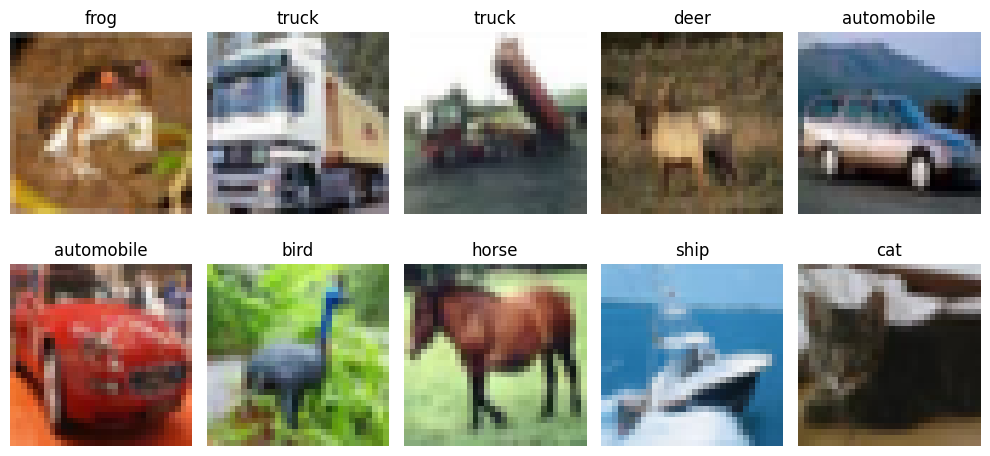

In [5]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [6]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [7]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2665 - loss: 1.9978 - val_accuracy: 0.3306 - val_loss: 1.8270
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3127 - loss: 1.8712 - val_accuracy: 0.3574 - val_loss: 1.8072
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3327 - loss: 1.8200 - val_accuracy: 0.3742 - val_loss: 1.7606
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3485 - loss: 1.7861 - val_accuracy: 0.3904 - val_loss: 1.7150
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3579 - loss: 1.7641 - val_accuracy: 0.4012 - val_loss: 1.6997
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3668 - loss: 1.7387 - val_accuracy: 0.3984 - val_loss: 1.7124
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3729 - loss: 1.7254 - val_accuracy: 0.4142 - val_loss: 1.7014
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3776 - loss: 1.7106 - val_accuracy: 0.

In [8]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4328 - loss: 1.6327
ANN Test Accuracy: 0.4327999949455261


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [9]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4631 - loss: 1.5082 - val_accuracy: 0.5384 - val_loss: 1.2594
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6087 - loss: 1.1218 - val_accuracy: 0.6174 - val_loss: 1.0887
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6725 - loss: 0.9443 - val_accuracy: 0.6442 - val_loss: 1.0629
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7150 - loss: 0.8255 - val_accuracy: 0.6954 - val_loss: 0.8890
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7452 - loss: 0.7309 - val_accuracy: 0.7122 - val_loss: 0.8303
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7728 - loss: 0.6508 - val_accuracy: 0.6950 - val_loss: 0.9187
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7944 - loss: 0.5887 - val_accuracy: 0.7002 - val_loss: 0.8986
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8118 - loss: 0.5345 - val_accuracy: 

In [10]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7021 - loss: 0.9960
CNN Test Accuracy: 0.7020999789237976


## 📈 Compare Learning Curves

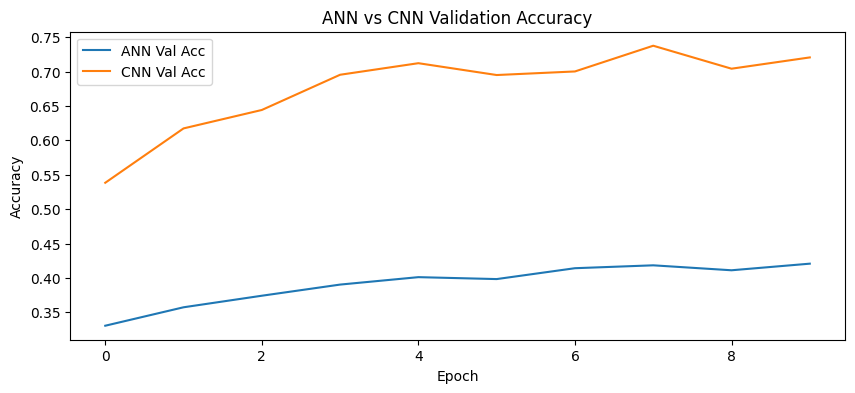

In [11]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.3681 - loss: 1.7182 - val_accuracy: 0.4786 - val_loss: 1.4338
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4654 - loss: 1.4855 - val_accuracy: 0.5584 - val_loss: 1.2214
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4976 - loss: 1.3941 - val_accuracy: 0.5876 - val_loss: 1.1435
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5260 - loss: 1.3268 - val_accuracy: 0.5910 - val_loss: 1.1277
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5423 - loss: 1.2909 - val_accuracy: 0.6076 - val_loss: 1.1000
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5528 - loss: 1.2580 - val_accuracy: 0.6088 - val_loss: 1.1164
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5679 - loss: 1.2234 - val_accuracy: 0.6368 - val_loss: 1.0326
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5756 - loss: 1.

# 📊 Final Comparison Table

In [13]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4328
1,CNN,0.7021


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

### ✅ Task 1 – Increase ANN Layers

In [14]:
print("Task 1: Increased ANN Layers")

ann_model_task = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model_task.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_task = ann_model_task.fit(
    x_train_flat,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_loss, ann_acc = ann_model_task.evaluate(x_test_flat, y_test)

print("Task 1 Test Accuracy:", ann_acc)

Task 1: Increased ANN Layers


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.2171 - loss: 2.0817 - val_accuracy: 0.2948 - val_loss: 1.9310
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2824 - loss: 1.9346 - val_accuracy: 0.3202 - val_loss: 1.8706
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2957 - loss: 1.8992 - val_accuracy: 0.3246 - val_loss: 1.8508
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3107 - loss: 1.8656 - val_accuracy: 0.3134 - val_loss: 1.8738
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3202 - loss: 1.8462 - val_accuracy: 0.3486 - val_loss: 1.8075
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3250 - loss: 1.8345 - val_accuracy: 0.3742 - val_loss: 1.7860
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3336 - loss: 1.8186 - val_accuracy: 0.3778 - val_loss: 1.7686
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3400 - loss: 1.8056 - val_accuracy: 0

### ✅ Task 2 – CNN Filters (32 → 64 → 128)

In [15]:
cnn_filters = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_filters.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_filters.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

cnn_loss, cnn_acc = cnn_filters.evaluate(x_test_norm, y_test)

print("Task 2 Accuracy:", cnn_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4513 - loss: 1.5470 - val_accuracy: 0.5164 - val_loss: 1.3501
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5847 - loss: 1.1759 - val_accuracy: 0.6058 - val_loss: 1.1338
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6463 - loss: 1.0097 - val_accuracy: 0.6338 - val_loss: 1.0276
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6854 - loss: 0.8983 - val_accuracy: 0.6790 - val_loss: 0.9195
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7159 - loss: 0.8138 - val_accuracy: 0.4392 - val_loss: 2.2444
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7409 - loss: 0.7368 - val_accuracy: 0.7066 - val_loss: 0.8598
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7635 - loss: 0.6741 - val_accuracy: 0.7208 - val_loss: 0.8151
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7833 - loss: 0.6198 - val_accuracy: 

### ✅ Task 3 increase epochs to 20 + Task 4 add EarlyStopping Together

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

print("Task 3 & 4: 20 Epochs with EarlyStopping")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_model_task = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model_task.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_task = cnn_model_task.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_loss, cnn_es_acc = cnn_model_task.evaluate(x_test_norm, y_test)

print("Task 3 & 4 Test Accuracy:", cnn_es_acc)

Task 3 & 4: 20 Epochs with EarlyStopping
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4541 - loss: 1.5439 - val_accuracy: 0.5000 - val_loss: 1.3513
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5883 - loss: 1.1610 - val_accuracy: 0.5776 - val_loss: 1.2225
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6445 - loss: 1.0100 - val_accuracy: 0.6128 - val_loss: 1.0889
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6829 - loss: 0.9014 - val_accuracy: 0.6322 - val_loss: 1.0231
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7191 - loss: 0.8088 - val_accuracy: 0.5350 - val_loss: 1.6946
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7420 - loss: 0.7350 - val_accuracy: 0.6830 - val_loss: 0.9307
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7611 - loss: 0.6812 - val_accuracy: 0.5474 - val_loss: 1.6741
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accurac

>As we used EarlyStopping here instead of doing all 20 epochs we stopped at 11th. As validation loss did not improve further.This helps model save training time and we get best fit model.

### ✅ Task 5 – Data Augmentation

In [18]:
print("Task 5: Data Augmentation Training")

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])

aug_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

aug_loss, aug_acc = aug_model.evaluate(x_test_norm, y_test)

print("Task 5 Accuracy:",aug_acc)

Task 5: Data Augmentation Training
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.3905 - loss: 1.7021 - val_accuracy: 0.4544 - val_loss: 1.5050
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4898 - loss: 1.4259 - val_accuracy: 0.4944 - val_loss: 1.4933
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5337 - loss: 1.3145 - val_accuracy: 0.5680 - val_loss: 1.2188
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5669 - loss: 1.2219 - val_accuracy: 0.5826 - val_loss: 1.2222
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5942 - loss: 1.1630 - val_accuracy: 0.6342 - val_loss: 1.0472
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6116 - loss: 1.1146 - val_accuracy: 0.5764 - val_loss: 1.2146
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6255 - loss: 1.0753 - val_accuracy: 0.6554 - val_loss: 0.9625
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accura

### 📊 Comparison Table

In [19]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Baseline ANN",
        "Enhanced ANN",
        "Baseline CNN",
        "CNN (32→64→128 Filters)",
        "CNN + EarlyStopping",
        "CNN + Data Augmentation"
    ],
    "Test Accuracy": [
        ann_test_acc,
        ann_acc,
        cnn_test_acc,
        cnn_acc,
        cnn_es_acc,
        aug_acc
    ]
})

comparison = comparison.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Test Accuracy
0,CNN + EarlyStopping,0.7137
1,CNN (32→64→128 Filters),0.7099
2,Baseline CNN,0.7021
3,CNN + Data Augmentation,0.6906
4,Baseline ANN,0.4328
5,Enhanced ANN,0.4038


### 📈 Bar Chart

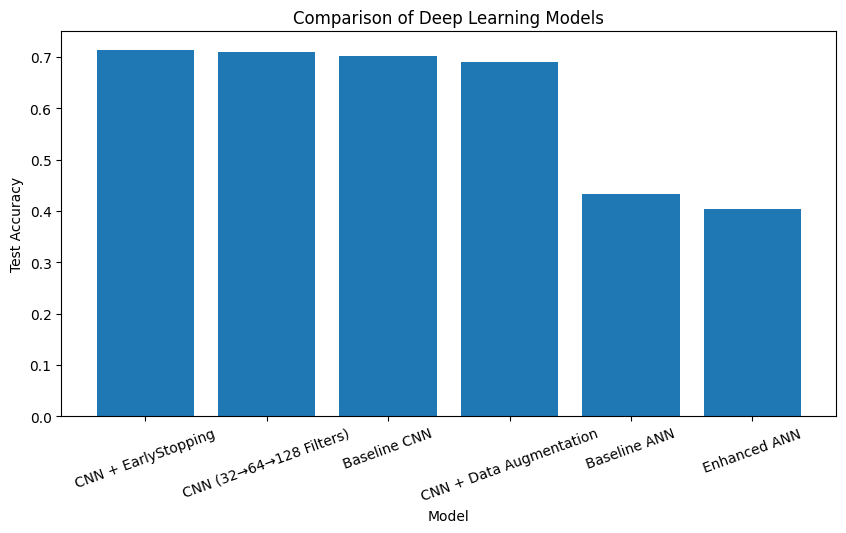

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(comparison["Model"], comparison["Test Accuracy"])

plt.title("Comparison of Deep Learning Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")

plt.xticks(rotation=20)

plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**